In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
dataset = pd.read_csv('Cleaned_forest_dataset.csv')

In [49]:
dataset.head()

,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [50]:
df = dataset.copy()

In [51]:
df.shape

(244, 15)

In [52]:
df.drop(['day',	'month', 'year'], axis=1, inplace=True) # drop day, month, year due to unimportance

In [53]:
df.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [54]:
df['classes'].value_counts()

classes
fire             132
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [55]:
df['classes'] = df['classes'].str.strip()

In [56]:
df['classes'].value_counts()

classes
fire        138
not fire    106
Name: count, dtype: int64

In [57]:
# Encoding the categorical feature --
df['classes'] = np.where(df['classes'].str.contains('not fire'), 1, 0)

In [58]:
df.dtypes

temperature      int64
rh               int64
ws               int64
rain           float64
ffmc           float64
dmc            float64
dc             float64
isi            float64
bui            float64
fwi            float64
classes          int64
region           int64
dtype: object

In [59]:
df.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,1,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,1,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,1,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,1,0


In [60]:
df.groupby('region')['temperature'].mean()

region
0    31.180328
1    33.163934
Name: temperature, dtype: float64

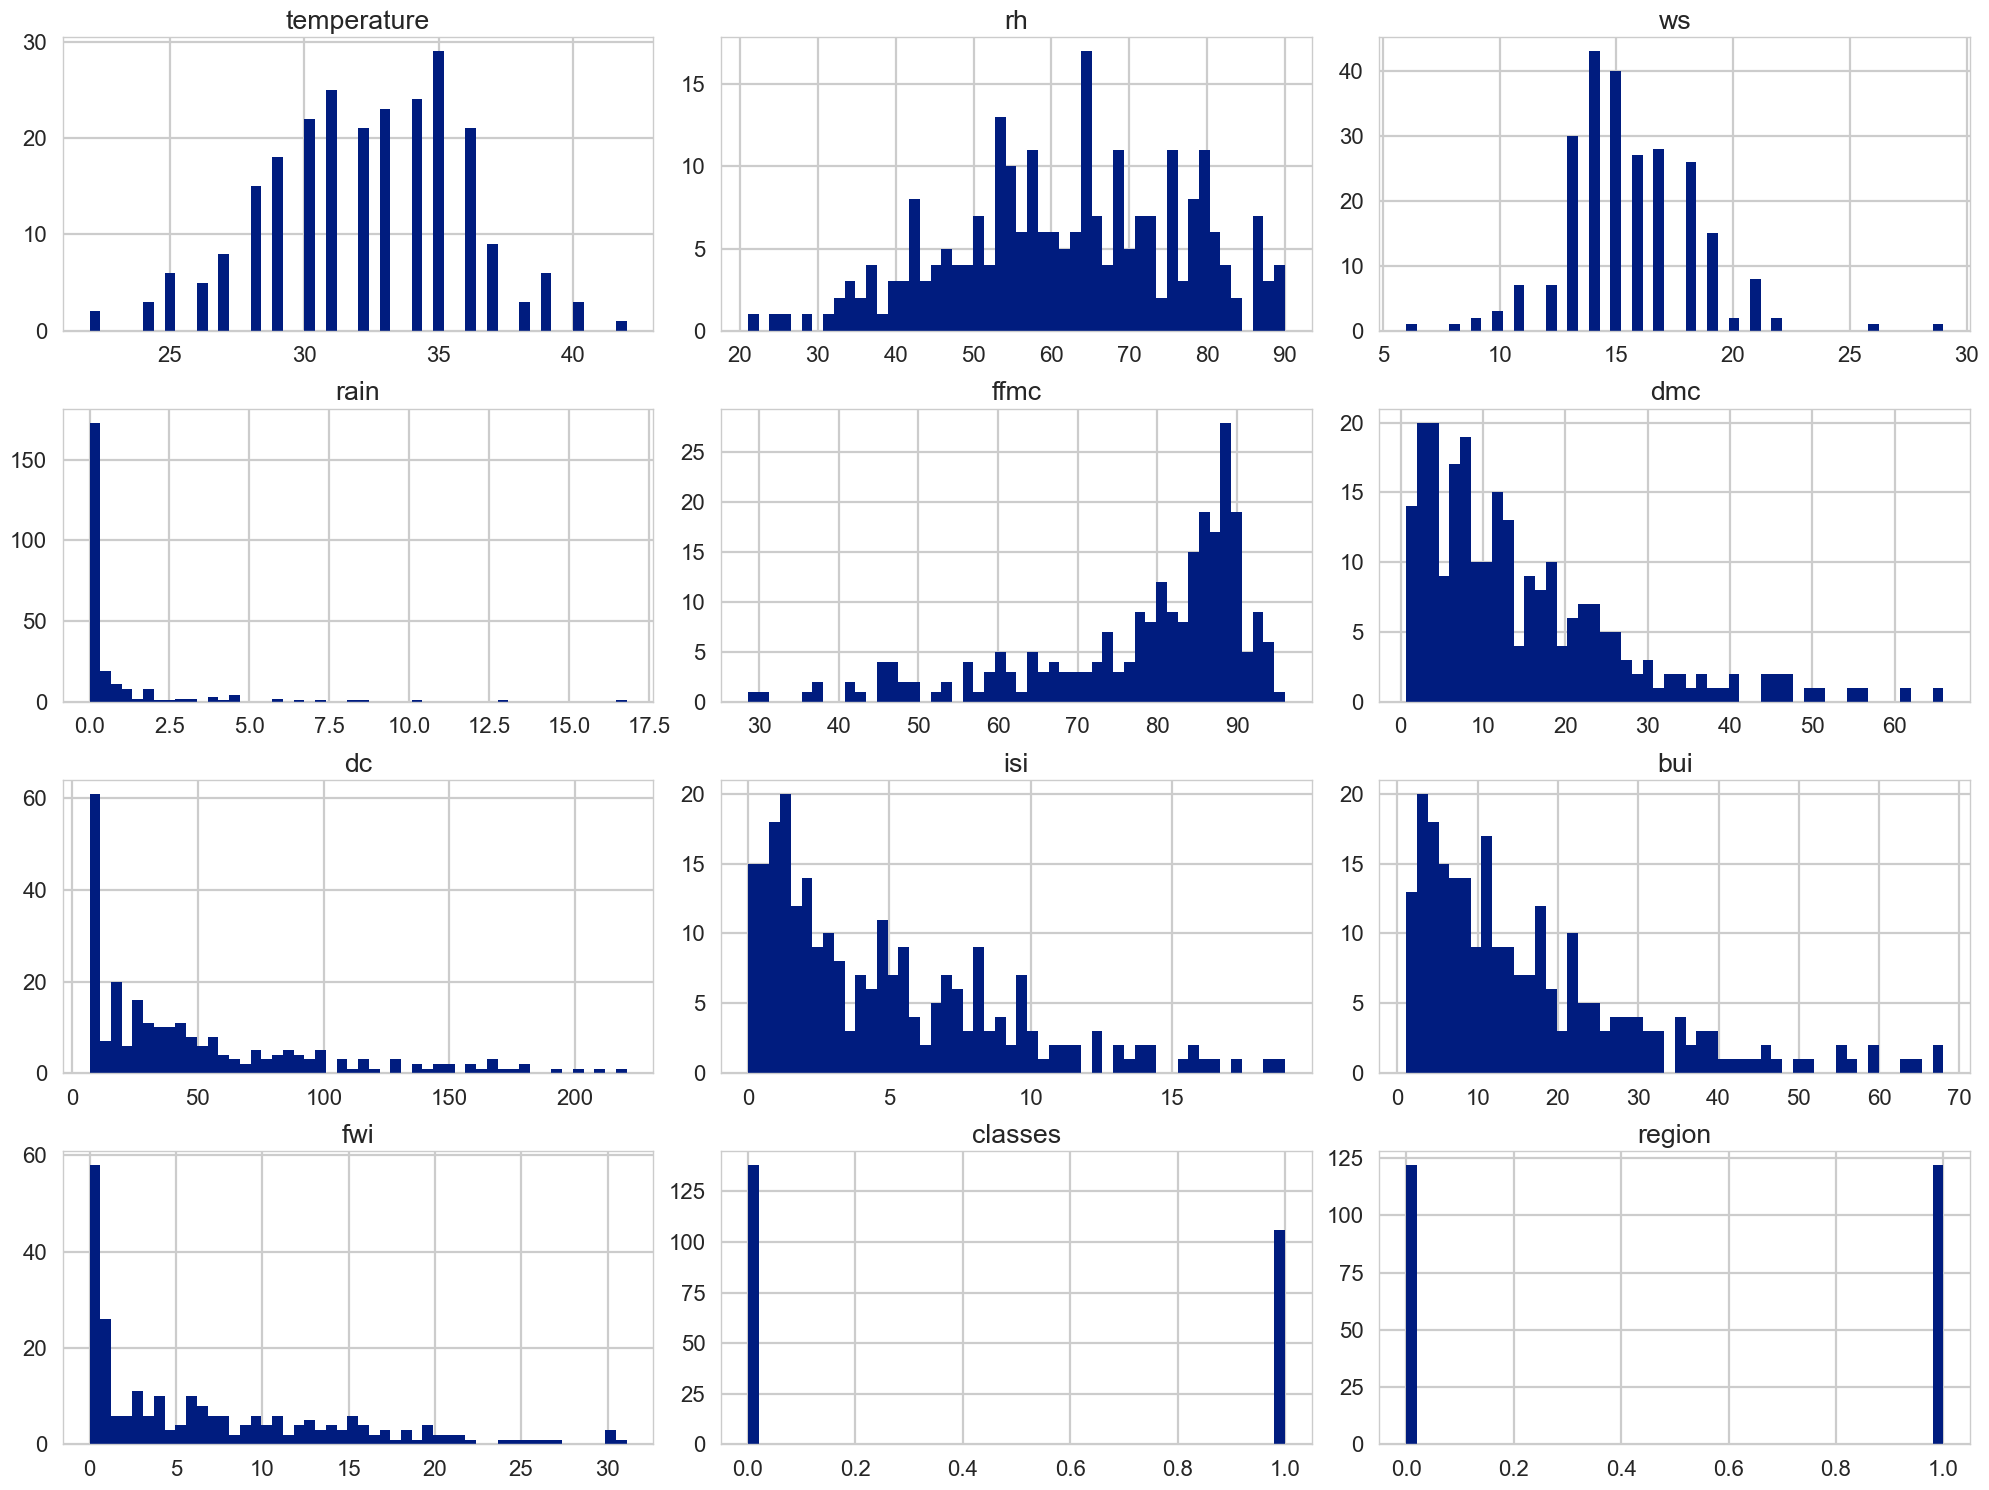

In [61]:
plt.style.use('seaborn-v0_8-dark-palette')
df.hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

In [65]:
density = df['classes'].value_counts(normalize=True)*100

In [66]:
labels=['Fire', 'Not Fire']

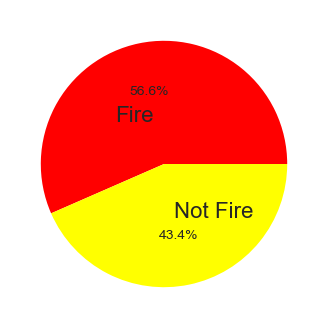

In [78]:
plt.figure(figsize=(6, 4))
plt.pie(x=density, labels=labels, autopct='%1.1f%%' ,labeldistance=.4, colors=['red', 'yellow'])
plt.show()

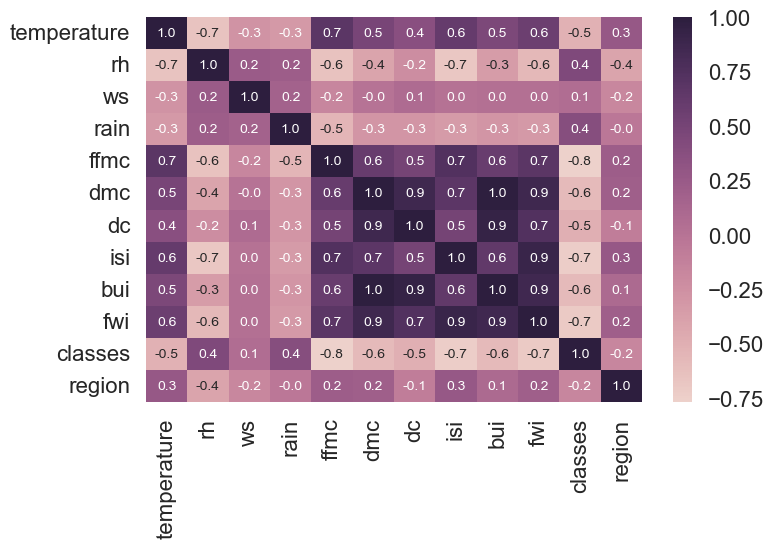

In [91]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, fmt='.1f',cmap=sns.cubehelix_palette(as_cmap=True))
plt.show()

#### month wise fire and Not fire situations data visualization 

In [155]:
df1 = pd.read_csv('Cleaned_forest_dataset.csv')

In [156]:
df_algeria = df1.loc[df['region'] == 0]
df_Sidi_Belabbes = df1.loc[df['region'] == 1]

In [157]:
df_algeria.loc[:,'classes'] = np.where( df_algeria['classes'].str.contains('not fire'), 0, 1)
df_Sidi_Belabbes.loc[:,'classes'] = np.where( df_Sidi_Belabbes['classes'].str.contains('not fire'), 0, 1)

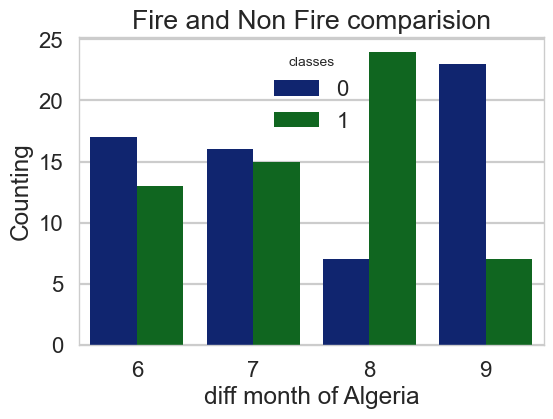

In [161]:
plt.figure(figsize=(6, 4))
sns.countplot(x='month', hue='classes', data=df_algeria)
plt.xlabel('diff month of Algeria')
plt.ylabel('Counting')
plt.title('Fire and Non Fire comparision')
plt.show()

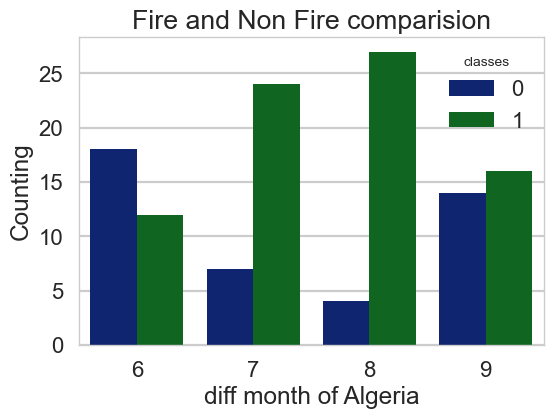

In [162]:
plt.figure(figsize=(6, 4))
sns.countplot(x='month', hue='classes', data=df_Sidi_Belabbes)
plt.xlabel('diff month of Algeria')
plt.ylabel('Counting')
plt.title('Fire and Non Fire comparision')
plt.show()

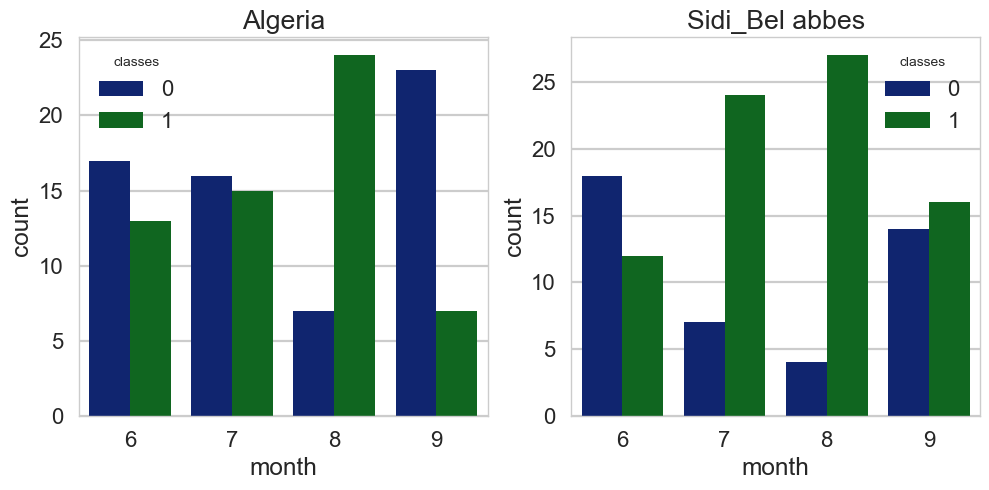

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# plt.subplot(1,2, 1)
# sns.countplot(x='month', hue='classes', data=df_Sidi_Belabbes)
# plt.title("Sidi_Bel abbes")

# plt.subplot(1,2, 2)
# sns.countplot(x='month', hue='classes', data=df_algeria)
# plt.title('Algeria')

sns.countplot(x='month', hue='classes', data=df_algeria, ax=axes[0])
axes[0].set_title('Algeria')

sns.countplot(x='month', hue='classes', data=df_Sidi_Belabbes, ax=axes[1])
axes[1].set_title("Sidi_Bel abbes")

plt.tight_layout()
plt.show()